In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("fifa_world_cup_2026_player_performance.csv")


# Basic Concept of Database

In [3]:
df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [4]:
df.shape

(54600, 75)

In [5]:
df.columns

Index(['player_id', 'player_name', 'age', 'nationality', 'team',
       'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot',
       'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_k

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  object 
 1   player_name               54600 non-null  object 
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  object 
 4   team                      54600 non-null  object 
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  object 
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  object 
 10  club_name                 54600 non-null  object 
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  object 
 13  match_date                54600 non-null  object 
 14  stadiu

In [7]:
df.describe()

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
count,54600.000000,54600.000000,54600.000000,54600.000000,5.460000e+04,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,...,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000
mean,26.296484,13.500000,181.654341,75.754853,2.008445e+07,1.330476,1.330476,36.199817,0.055385,0.052363,...,2.850165,60.318379,46.135778,63.750396,55.572154,0.643993,0.607601,272.300311,0.030659,3.634046
std,4.067519,7.500069,6.277792,3.951481,2.718866e+07,1.147814,1.147814,36.419755,0.251900,0.239021,...,4.228436,20.234988,22.424337,19.860028,13.661343,1.093781,0.931527,116.806184,0.206520,3.163411
min,17.000000,1.000000,163.000000,65.000000,5.288220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,15.000000,5.000000,25.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,7.000000,177.000000,73.000000,4.444778e+06,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,43.700000,29.800000,46.500000,46.400000,0.000000,0.000000,184.000000,0.000000,0.000000
50%,26.000000,13.500000,182.000000,76.000000,1.027111e+07,1.000000,1.000000,24.000000,0.000000,0.000000,...,1.100000,57.000000,40.500000,61.100000,55.000000,0.000000,0.000000,268.000000,0.000000,5.400000
75%,29.000000,20.000000,186.000000,78.000000,2.342013e+07,2.000000,2.000000,75.000000,0.000000,0.000000,...,4.000000,75.100000,59.000000,78.900000,63.900000,1.000000,1.000000,359.000000,0.000000,6.400000
max,39.000000,26.000000,200.000000,87.000000,2.000000e+08,7.000000,7.000000,90.000000,4.000000,3.000000,...,37.000000,99.000000,99.000000,99.000000,99.000000,10.000000,8.000000,615.000000,4.000000,9.500000


In [8]:
df.isnull().sum()

player_id                   0
player_name                 0
age                         0
nationality                 0
team                        0
                           ..
total_goals_tournament      0
total_assists_tournament    0
total_minutes_tournament    0
player_of_match_awards      0
tournament_rating           0
Length: 75, dtype: int64

In [9]:
df["match_result"].value_counts()

match_result
W    20124
L    20124
D    14352
Name: count, dtype: int64

# Data Cleaning

In [10]:
df_clean=df.copy()
print("Database copies Succesfully")

Database copies Succesfully


In [11]:
missing_value=df_clean.isnull().sum()
missing_value

player_id                   0
player_name                 0
age                         0
nationality                 0
team                        0
                           ..
total_goals_tournament      0
total_assists_tournament    0
total_minutes_tournament    0
player_of_match_awards      0
tournament_rating           0
Length: 75, dtype: int64

In [12]:
df_clean.isnull().sum().sum()

np.int64(0)

In [13]:
df_clean.drop_duplicates(inplace=True)

In [14]:
df_clean.duplicated().sum()

np.int64(0)

In [15]:
print("Original Shape :", df.shape)
print("Cleaned Shape  :", df_clean.shape)

Original Shape : (54600, 75)
Cleaned Shape  : (54600, 75)


# Exploration of data modeling

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

%matplotlib inline

In [17]:
df_clean["match_result"].value_counts()

match_result
W    20124
L    20124
D    14352
Name: count, dtype: int64

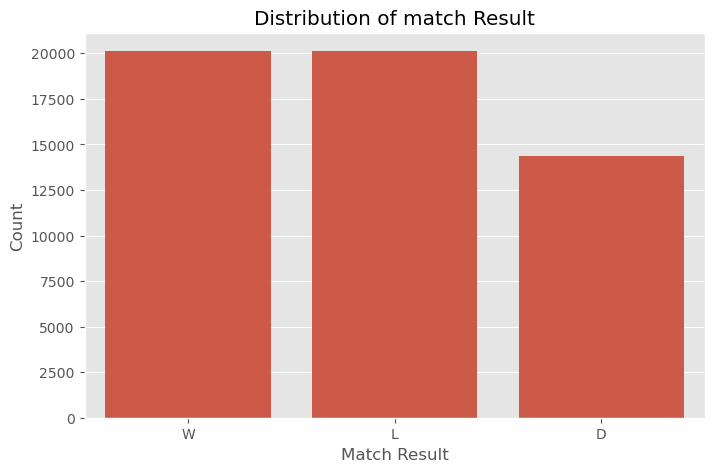

In [18]:
# Visualize Target Variable
plt.figure(figsize=(8,5))

sns.countplot(x="match_result",data=df_clean)

plt.title("Distribution of match Result")
plt.xlabel("Match Result")
plt.ylabel("Count")

plt.show()

### numerical values

In [19]:
numerical_column=df_clean.select_dtypes(include=["int64","float"]).columns
print(numerical_column)

Index(['age', 'jersey_number', 'height_cm', 'weight_kg', 'market_value_eur',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh',
       'accelerations', 'decelerations', 'stamina_score', 'player_rating',
       'performance_score', 'offensive_contribution', 'defensive_contribution',
       'possession_impact', 'pressure_resistance', 'c

### Statistical Summary

In [20]:
df_clean[numerical_column].describe().T

,count,mean,std,min,25%,50%,75%,max
age,54600.0,2.629648e+01,4.067519e+00,17.0,23.0,26.0,29.0,39.0
jersey_number,54600.0,1.350000e+01,7.500069e+00,1.0,7.0,13.5,20.0,26.0
height_cm,54600.0,1.816543e+02,6.277792e+00,163.0,177.0,182.0,186.0,200.0
weight_kg,54600.0,7.575485e+01,3.951481e+00,65.0,73.0,76.0,78.0,87.0
market_value_eur,54600.0,2.008445e+07,2.718866e+07,528822.0,4444778.0,10271107.0,23420128.0,200000000.0
...,...,...,...,...,...,...,...,...
total_goals_tournament,54600.0,6.439927e-01,1.093781e+00,0.0,0.0,0.0,1.0,10.0
total_assists_tournament,54600.0,6.076007e-01,9.315267e-01,0.0,0.0,0.0,1.0,8.0
total_minutes_tournament,54600.0,2.723003e+02,1.168062e+02,0.0,184.0,268.0,359.0,615.0
player_of_match_awards,54600.0,3.065934e-02,2.065200e-01,0.0,0.0,0.0,0.0,4.0


### Histograms

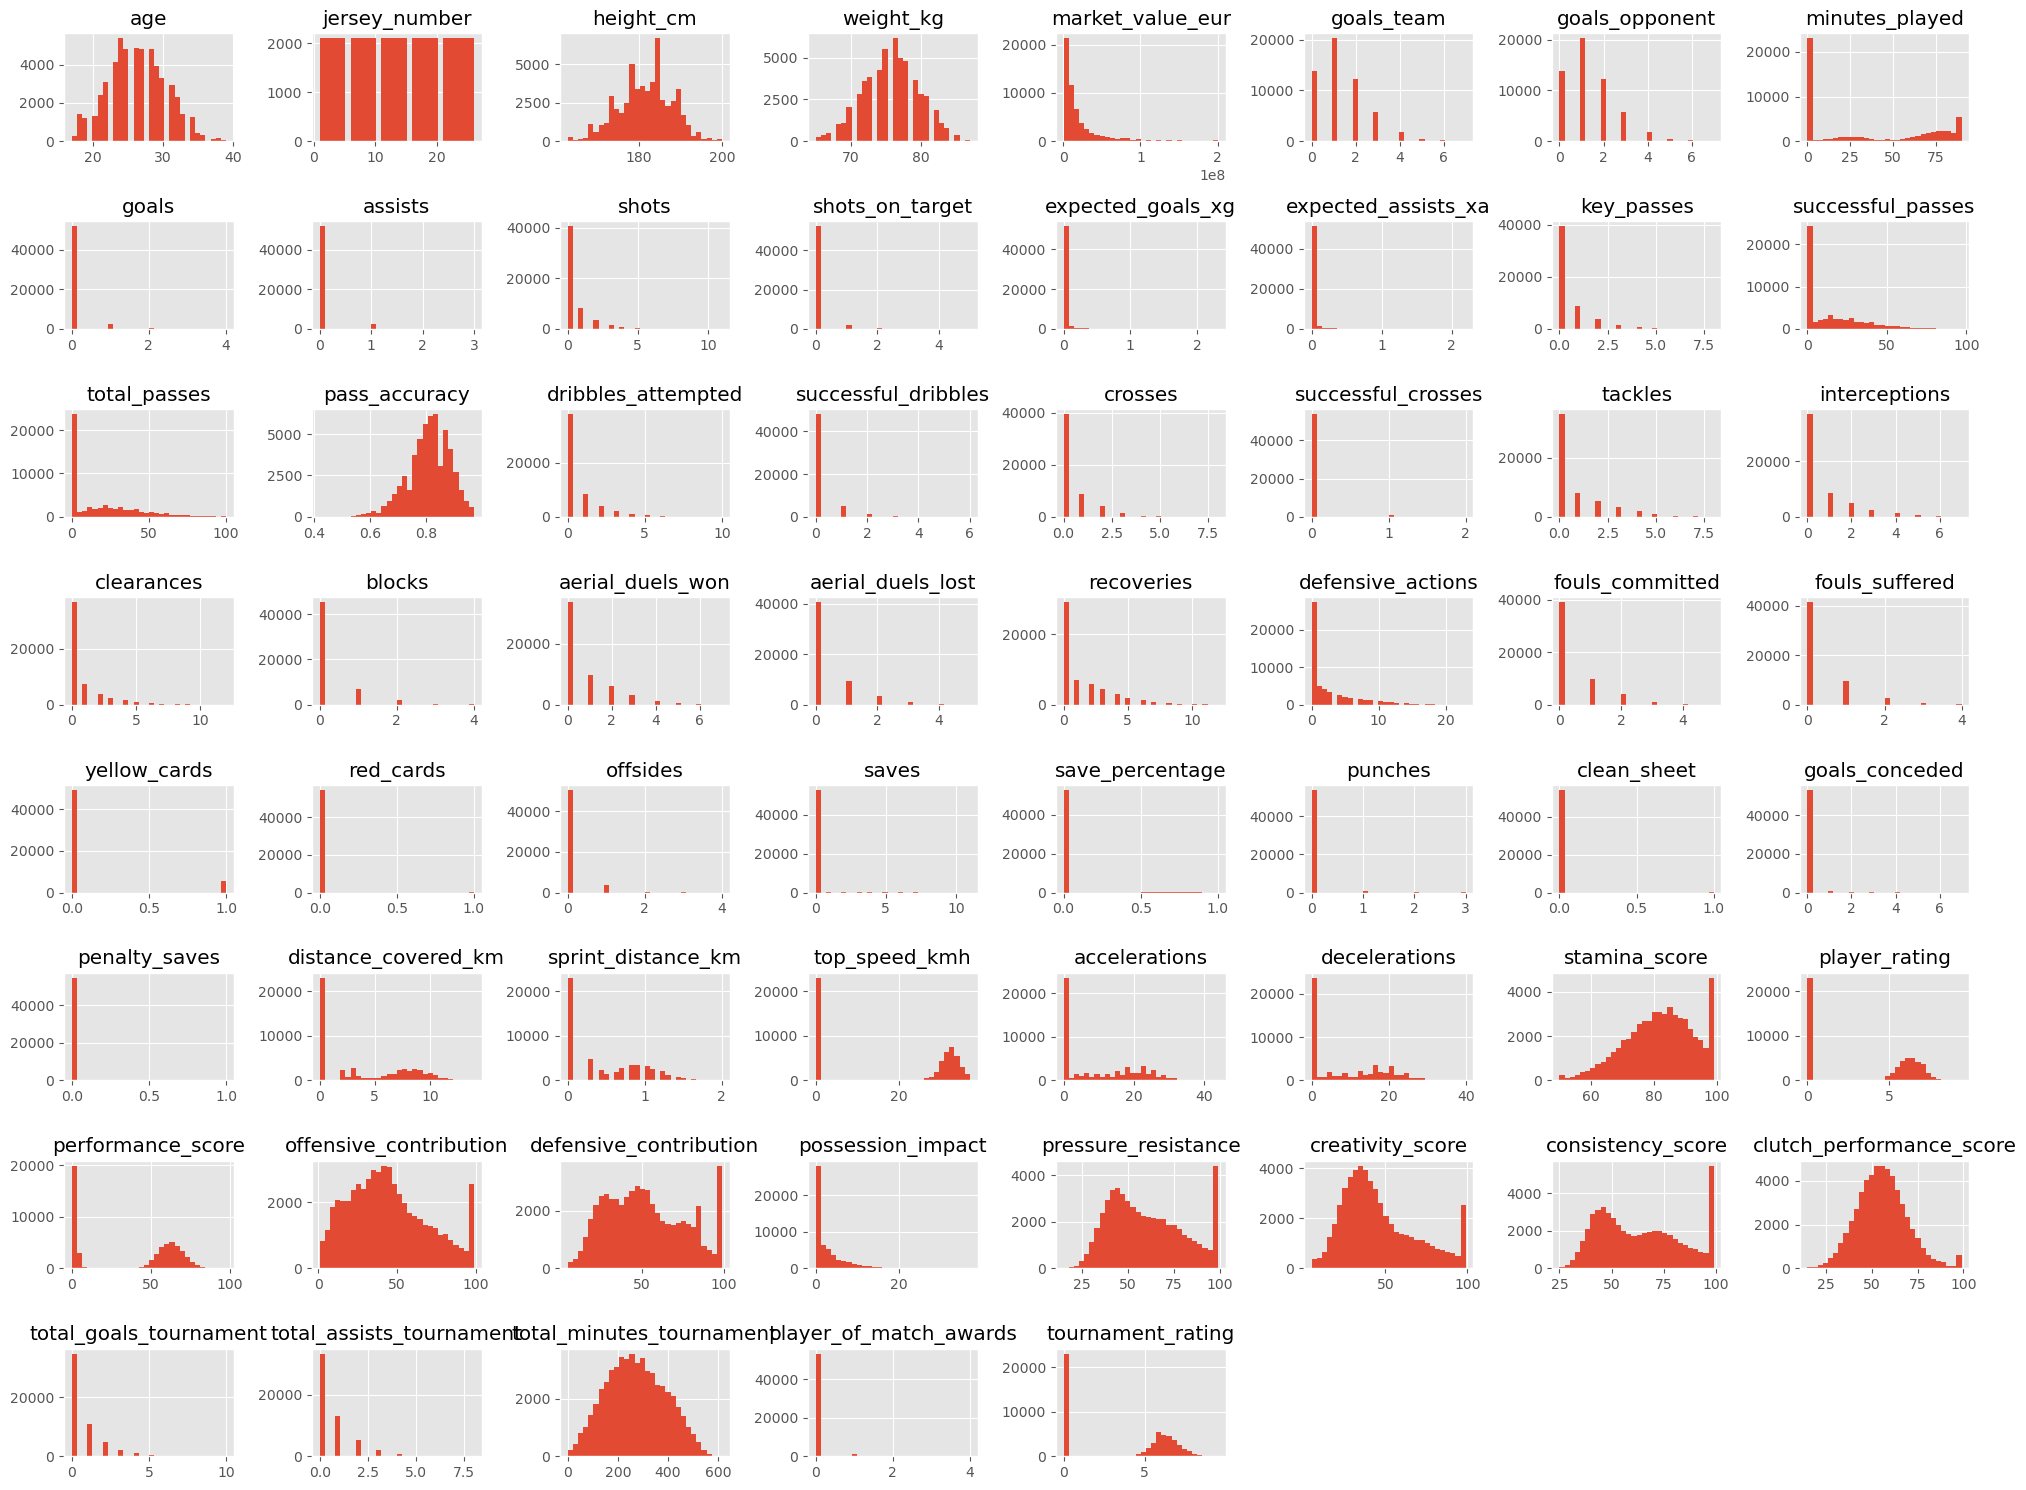

In [21]:
df_clean[numerical_column].hist(
          figsize=(20,15),
          bins=30
)
plt.tight_layout()
plt.show()

### Boxplots

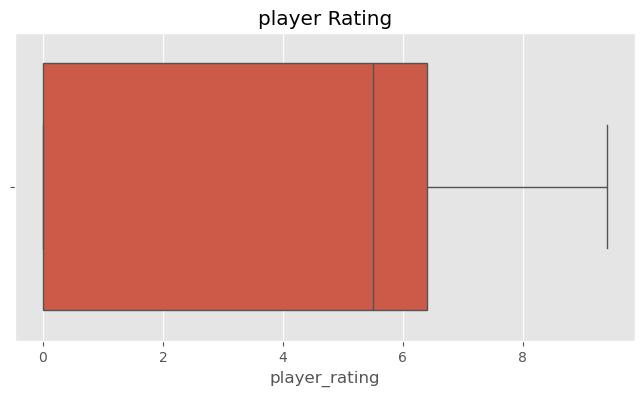

In [22]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean["player_rating"])
plt.title("player Rating")
plt.show()


### correlation Matrix

In [23]:
correlation=df_clean[numerical_column].corr()
correlation

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
age,1.000000,-0.191316,0.124882,0.093327,-0.068914,-6.428752e-03,1.683938e-03,-0.022833,-0.036548,-0.027272,...,-0.052197,-0.055096,-0.147483,-0.057637,-0.006452,-0.099839,-0.098019,-0.011190,-0.025517,-0.038990
jersey_number,-0.191316,1.000000,-0.486071,-0.319660,0.187251,4.453502e-17,4.339367e-17,0.061657,0.182235,0.110867,...,0.074454,0.034995,0.568534,0.034015,0.008626,0.526784,0.364273,0.014613,0.090411,0.110570
height_cm,0.124882,-0.486071,1.000000,0.630950,-0.112356,2.419965e-03,-4.297944e-03,-0.041854,-0.081591,-0.068021,...,-0.072385,-0.013760,-0.314955,-0.018848,-0.001603,-0.244723,-0.224186,-0.010504,-0.047627,-0.079246
weight_kg,0.093327,-0.319660,0.630950,1.000000,-0.073950,-6.431085e-03,1.289886e-03,-0.021524,-0.060550,-0.039387,...,-0.036368,-0.019334,-0.184050,-0.021363,-0.000473,-0.168261,-0.127640,-0.001755,-0.033163,-0.047990
market_value_eur,-0.068914,0.187251,-0.112356,-0.073950,1.000000,-3.511289e-03,1.612354e-03,0.017773,0.093392,0.081924,...,0.347035,0.594907,0.466853,0.624168,0.111797,0.121565,0.088259,0.000860,0.088152,0.074993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
total_goals_tournament,-0.099839,0.526784,-0.244723,-0.168261,0.121565,6.372242e-03,2.695916e-03,0.072074,0.341717,0.078241,...,0.042889,0.026330,0.312111,0.026546,0.008342,1.000000,0.278294,0.241801,0.155998,0.091238
total_assists_tournament,-0.098019,0.364273,-0.224186,-0.127640,0.088259,-3.486700e-03,-2.818644e-03,0.079970,0.077165,0.307885,...,0.115917,0.030114,0.296283,0.024850,0.009065,0.278294,1.000000,0.272720,0.141938,0.097110
total_minutes_tournament,-0.011190,0.014613,-0.010504,-0.001755,0.000860,-2.085579e-03,-3.046484e-03,0.312868,0.064891,0.069086,...,0.209072,-0.000315,0.007218,-0.001877,-0.000082,0.241801,0.272720,1.000000,0.102657,0.260638
player_of_match_awards,-0.025517,0.090411,-0.047627,-0.033163,0.088152,3.695465e-04,-1.793868e-03,0.143611,0.324354,0.327383,...,0.174037,0.072808,0.110730,0.077475,0.024091,0.155998,0.141938,0.102657,1.000000,0.144761


### Haetmap

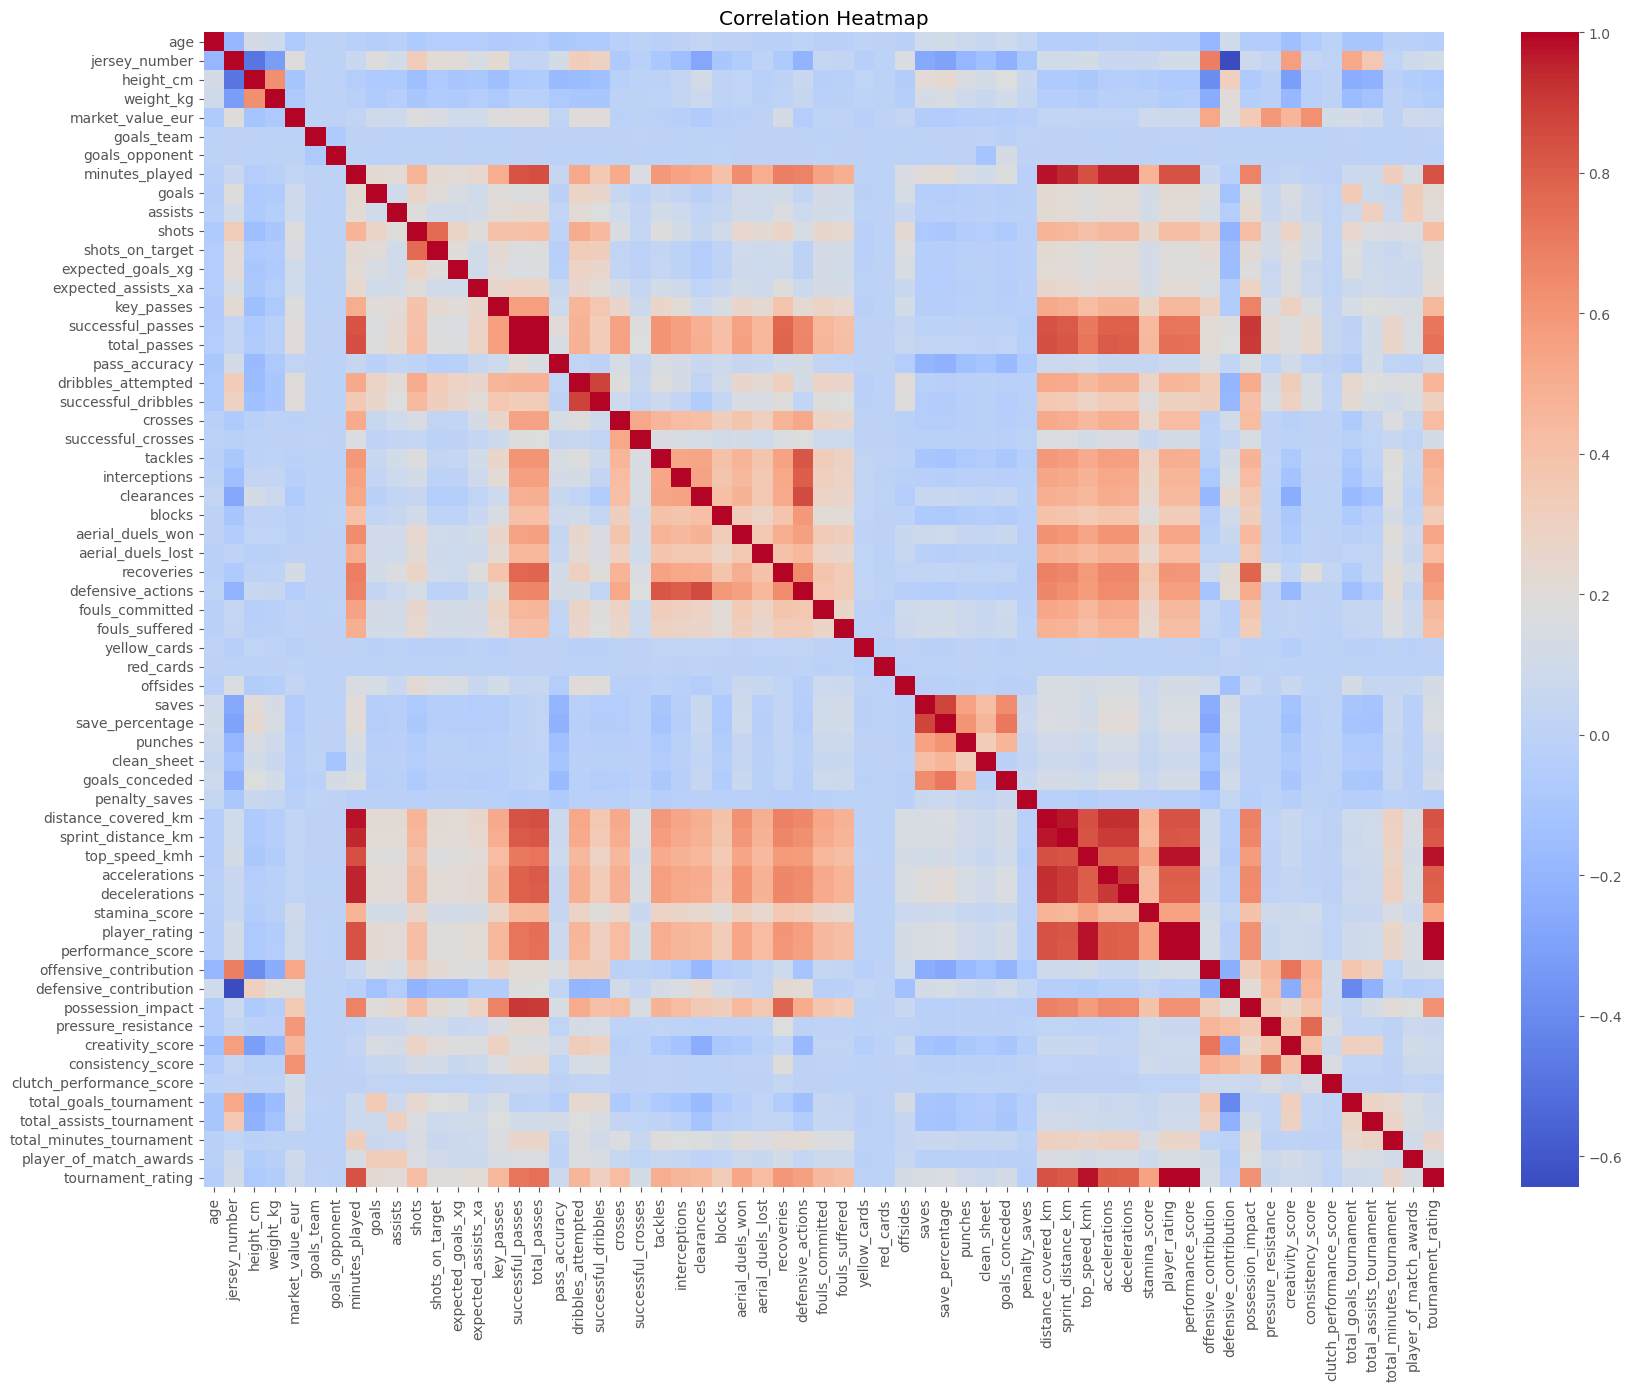

In [24]:
plt.figure(figsize=(20,15))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

### Categorical Columns

In [25]:
categorical_columns = df_clean.select_dtypes(include="object").columns

categorical_columns

Index(['player_id', 'player_name', 'nationality', 'team', 'position',
       'preferred_foot', 'club_name', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result'],
      dtype='object')

### count plot example

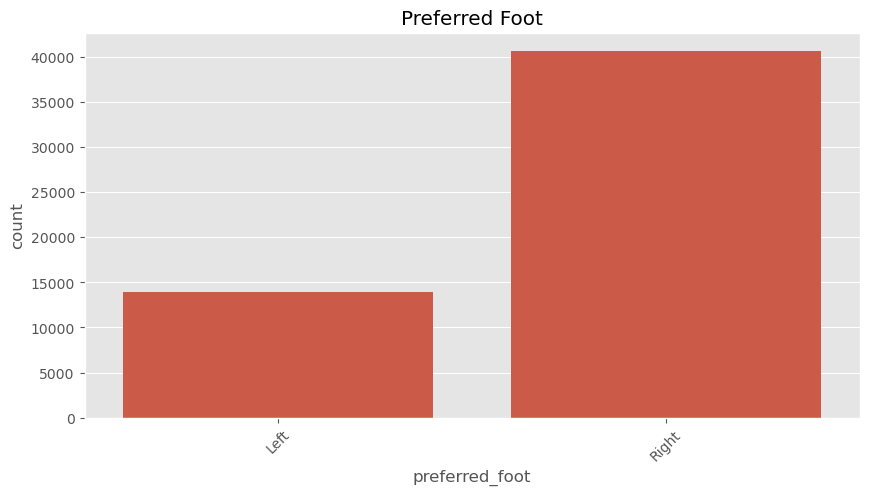

In [26]:
plt.figure(figsize=(10,5))

sns.countplot(x="preferred_foot", data=df_clean)

plt.title("Preferred Foot")

plt.xticks(rotation=45)

plt.show()

# Data preprocessing and Feature Engineering

In [27]:
df_clean.columns.tolist()

['player_id',
 'player_name',
 'age',
 'nationality',
 'team',
 'jersey_number',
 'position',
 'height_cm',
 'weight_kg',
 'preferred_foot',
 'club_name',
 'market_value_eur',
 'match_id',
 'match_date',
 'stadium',
 'city',
 'opponent_team',
 'tournament_stage',
 'match_result',
 'goals_team',
 'goals_opponent',
 'minutes_played',
 'goals',
 'assists',
 'shots',
 'shots_on_target',
 'expected_goals_xg',
 'expected_assists_xa',
 'key_passes',
 'successful_passes',
 'total_passes',
 'pass_accuracy',
 'dribbles_attempted',
 'successful_dribbles',
 'crosses',
 'successful_crosses',
 'tackles',
 'interceptions',
 'clearances',
 'blocks',
 'aerial_duels_won',
 'aerial_duels_lost',
 'recoveries',
 'defensive_actions',
 'fouls_committed',
 'fouls_suffered',
 'yellow_cards',
 'red_cards',
 'offsides',
 'saves',
 'save_percentage',
 'punches',
 'clean_sheet',
 'goals_conceded',
 'penalty_saves',
 'distance_covered_km',
 'sprint_distance_km',
 'top_speed_kmh',
 'accelerations',
 'decelerations',

### target Variable

In [28]:
target_column = "match_result"

y = df_clean[target_column]

print("Target Variable:")
print(y.head())

Target Variable:
0    W
1    W
2    W
3    W
4    W
Name: match_result, dtype: object


### Select Feature

In [29]:
X=df_clean.drop(columns=[target_column])
print("Feaature shape;",X.shape)

Feaature shape; (54600, 74)


### Identify Categorical Columns

In [30]:
categorical_columns = X.select_dtypes(include=["object"]).columns

print(categorical_columns)

Index(['player_id', 'player_name', 'nationality', 'team', 'position',
       'preferred_foot', 'club_name', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage'],
      dtype='object')


### Identify Numerical Columns

In [31]:
numerical_columns=X.select_dtypes(include=["int64" ,"float64"]).columns
print(numerical_columns)

Index(['age', 'jersey_number', 'height_cm', 'weight_kg', 'market_value_eur',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh',
       'accelerations', 'decelerations', 'stamina_score', 'player_rating',
       'performance_score', 'offensive_contribution', 'defensive_contribution',
       'possession_impact', 'pressure_resistance', 'c

### Encode Categorical Features

In [32]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for column in categorical_columns:
    X[column] = label_encoder.fit_transform(X[column].astype(str))

print("Categorical columns encoded successfully.")

Categorical columns encoded successfully.


### Encode target Variable

In [33]:
target_encoder=LabelEncoder()
y=target_encoder.fit_transform(y)
print("target Varible encode successfully")

target Varible encode successfully


In [34]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 74 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  int64  
 1   player_name               54600 non-null  int64  
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  int64  
 4   team                      54600 non-null  int64  
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  int64  
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  int64  
 10  club_name                 54600 non-null  int64  
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  int64  
 13  match_date                54600 non-null  int64  
 14  stadiu

In [35]:
X.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,54,998,26,40,39,3,2,195,75,0,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,69,136,19,40,39,18,3,178,75,1,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,65,427,18,40,39,14,3,177,72,0,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,72,922,20,40,39,21,1,182,74,1,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,58,90,23,40,39,7,0,191,81,0,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [36]:
print(y[:10])

[2 2 2 2 2 2 2 2 2 2]


In [37]:
print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (54600, 74)
Target Shape   : (54600,)


# Train-Test Split & Feature Scaling

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Split the Dataset

In [39]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [40]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (43680, 74)
Testing Features  : (10920, 74)
Training Target   : (43680,)
Testing Target    : (10920,)


### Apply feature Scaling

In [41]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [42]:
print(type(X_train_scaled))

<class 'numpy.ndarray'>


### Display the First Few Rows

In [43]:
import pandas as pd

X_train_scaled=pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled=pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

X_train_scaled.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,-1.484735,-0.224515,2.139380,-0.480953,-0.622991,0.732512,1.297454,-1.219582,1.577212,0.587220,...,1.504193,0.857951,0.754636,1.586925,-0.732156,0.327326,0.421242,0.518883,-0.149302,0.748100
1,-0.154188,-0.780674,1.401744,1.642178,1.648838,-1.535081,0.492923,0.533483,1.324588,0.587220,...,-0.270897,-0.253767,-1.168866,-0.932236,2.104344,-0.588834,-0.653767,-0.063905,-0.149302,0.937867
2,0.663108,-0.744704,0.664108,-0.188107,-0.329852,-0.601366,-1.116140,0.852222,1.324588,0.587220,...,-0.152558,1.371812,0.009335,1.415964,0.262081,-0.588834,-0.653767,-1.135208,-0.149302,1.064378
3,1.695188,0.334412,-1.794677,1.056487,0.989275,0.198961,1.297454,-1.219582,-1.454278,0.587220,...,1.598865,-0.046247,1.615972,0.179011,-0.330075,0.327326,0.421242,0.741714,4.692211,0.811356
4,-0.293658,0.301208,-1.057041,-0.993433,-1.062700,-1.268305,-1.116140,0.055374,0.061467,-1.702939,...,0.060453,-0.085774,-0.477119,-1.238961,0.305945,-0.588834,-0.653767,0.433179,-0.149302,0.748100


# Train Multiple Machine Learning Models

### Logistic Regression

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score

In [49]:
# Create models

lr= LogisticRegression(random_state=42)
dt=DecisionTreeClassifier(random_state=42)
rf=RandomForestClassifier(random_state=42)
knn=KNeighborsClassifier()
svm=SVC(random_state=42)
nb=GaussianNB()

### Train Logistic Regression

In [46]:
lr.fit(X_train_scaled,y_train)
lr_pred =lr.predict(X_test_scaled)
lr_accuracy =accuracy_score(y_test,lr_pred)
print("Logistic Regression Accuracy;",lr_accuracy)

Logistic Regression Accuracy; 1.0


### Train Decision tree

In [50]:
dt.fit(X_train,y_train)
dt_pred = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test,dt_pred)
print("Decision Tree Accuracy:",dt_accuracy)

Decision Tree Accuracy: 1.0


### Train Random Subset

In [51]:
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)
rf_accuracy = accuracy_score(y_test,rf_pred)
print("Random Forest Accuracy:", rf_accuracy)


Random Forest Accuracy: 1.0


### Train KNN Model

In [55]:
knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy :", knn_accuracy)

KNN Accuracy : 0.5826923076923077


### Train Svm

In [56]:
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, svm_pred)
print("SVM Accuracy :", svm_accuracy)

SVM Accuracy : 0.9903846153846154


### Train Naive Bayes

In [57]:
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_pred)
print("Naive Bayes Accuracy :", nb_accuracy)

Naive Bayes Accuracy : 0.37957875457875456


In [58]:
results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM",
        "Naive Bayes"
    ],

    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        svm_accuracy,
        nb_accuracy
    ]
}

comparison = pd.DataFrame(results)

comparison

,Model,Accuracy
0,Logistic Regression,1.000000
1,Decision Tree,1.000000
2,Random Forest,1.000000
3,KNN,0.582692
4,SVM,0.990385
5,Naive Bayes,0.379579


In [59]:
comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,1.000000
1,Decision Tree,1.000000
2,Random Forest,1.000000
4,SVM,0.990385
3,KNN,0.582692
5,Naive Bayes,0.379579
